# The General Signature Kernel — one object, six kernels

`ksig.generalized.GeneralSignatureKernel` (GSK) is a **single configurable
object** that reproduces six signature-based kernels. Five are the *same*
normalize-once kernel
$$K_\varphi=\sum_{k\ge0}\varphi(k)\,K_k$$
under a choice of **order-weighting** $\varphi(k)$, **truncation depth**, and
**normalization**; the sixth (`sig-EXACT`) is a legacy per-level-normalized
average kept for its inductive bias. $K_k$ is the level-$k$ signature kernel
$\langle S^k(x),S^k(y)\rangle$ — homogeneous of degree $k$ — so *choosing a
kernel is choosing $\varphi$*.

This notebook is the **map of the family**: what each column is, and — the
centerpiece — **which kernel reads which structural locus of a path**, measured
as out-of-sample kernel–target alignment (CKA) on six level-localized
data-generating processes. The companion **`X_learned_kernel.ipynb`** zooms into
the two *learnable* columns (`sig-Wphi`, `sig-PDEphi`) and the order-recovery
question.

Reference: `docs/SIGNATURE_KERNELS.md` (derives all six as specializations of one
skeleton); the matrix below is pinned by
`tests/test_signature_kernel_inductive_bias.py`.

## Environment
Detect the live backend/device. The GSK demos run on CPU (small, reproducible); the throughput story for the ported kernels is in notebooks `01`–`06`.

In [1]:
import sys, pathlib
_nbdir = pathlib.Path.cwd()
_root = _nbdir.parent if (_nbdir / "_nbtools.py").exists() else _nbdir
_nbdir = _root / "notebooks"
for _p in (str(_nbdir), str(_root)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import matplotlib.pyplot as plt
import ksig
ksig.set_default_device("cpu")          # statistical demos run on CPU (small, reproducible)
import _nbtools as nb
import _gsk_demo as g
%matplotlib inline

ENV = nb.detect_env()
nb.print_env_banner(ENV)
print("GSK demo  | paths/DGP:", g.N_TRAIN, "| length:", g.L, "| channels:", g.D,
      "| truncation N:", g.N_LEVELS, "| fit steps:", g.FIT_STEPS)

[2026-06-11 23:53:39,854] [INFO] [real_accelerator.py:260:get_accelerator] Setting ds_accelerator to xpu (auto detect)


icx: warning: -Wl,-z,noexecstack,-z,relro,-z,now,-rpath,$ORIGIN/../..,-rpath,$ORIGIN/../../..: 'linker' input unused [-Wunused-command-line-argument]
icx: warning: -Wl,-z,noexecstack,-z,relro,-z,now,-rpath,$ORIGIN/../..,-rpath,$ORIGIN/../../..: 'linker' input unused [-Wunused-command-line-argument]
/usr/bin/ld: /tmp/siebenschuh/tmph5a1hp8n/test.o: in function `main':
test.c:(.text+0x25): undefined reference to `io_pgetevents'
icx: error: linker command failed with exit code 1 (use -v to see invocation)


/opt/aurora/25.190.0/frameworks/aurora_frameworks-2025.2.0/lib/python3.10/site-packages/torch/xpu/__init__.py:60: UserWarning: XPU device count is zero! (Triggered internally at /lus/tegu/projects/datasets/software/wheelforge/repositories/pytorch_2p8_rel_07_18_2025/pytorch/c10/xpu/XPUFunctions.cpp:115.)
  return torch._C._xpu_getDeviceCount()


/opt/aurora/25.190.0/frameworks/aurora_frameworks-2025.2.0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-06-11 23:53:45,586] [INFO] [logging.py:107:log_dist] [Rank -1] [TorchCheckpointEngine] Initialized with serialization = False


ksig backend : torch  |  device: cpu  |  SYCL: absent (no 2nd curve)  |  ksig unknown
GSK demo  | paths/DGP: 120 | length: 22 | channels: 2 | truncation N: 3 | fit steps: 200


## The six columns

| column | `phi` | `truncation` | `normalize` | $\varphi(k)$ | learns? |
|---|---|---|---|---|---|
| `sig-L1` | `level_one` | $N$ | `once` | $e_1$ (level-1 only) | no |
| `sig-TRUNC` | `const` | $N$ | `once` | $1$ (truncated) | no |
| `sig-PDE` | `const` | `None` | `once` | $1$ (Goursat, untruncated) | no |
| `sig-Wphi` | `free` | $N$ | `once` | $\mathrm{softplus}(\theta)\ge0$ | **yes** |
| `sig-PDEphi` | `dilation` | `None` | `once` | $\sum_i w_i\lambda_i^{k}$ | **yes** |
| `sig-EXACT` | `const` | $N$ | `per_level` | $1$, per-level whitened | no |

$\varphi(0)\equiv1$ on every arm (the rank-1 level $K_0=\mathbf{1}\mathbf{1}^\top$
is weighted identically), so cross-column deltas carry no level-0 mismatch. The
cell below builds each fixed-$\varphi$ column and prints its $\varphi$ profile.

In [2]:
for name, (phi, trunc, norm) in {
        "sig-L1":    ("level_one", g.N_LEVELS, "once"),
        "sig-TRUNC": ("const",     g.N_LEVELS, "once"),
        "sig-PDE":   ("const",     None,       "once"),
        "sig-EXACT": ("const",     g.N_LEVELS, "per_level"),
}.items():
    k = g.gsk(phi, trunc, normalize=norm, bw=1.0)
    print(f"{name:10s}  phi(0:N) = {np.round(k.phi_profile(g.N_LEVELS), 3)}")
print("\n(sig-Wphi / sig-PDEphi learn phi from data -> see X_learned_kernel.ipynb)")

sig-L1      phi(0:N) = [0. 1. 0. 0.]
sig-TRUNC   phi(0:N) = [1. 1. 1. 1.]
sig-PDE     phi(0:N) = [1. 1. 1. 1.]
sig-EXACT   phi(0:N) = [1. 1. 1. 1.]

(sig-Wphi / sig-PDEphi learn phi from data -> see X_learned_kernel.ipynb)


## The data each kernel excels on

Six **level-localized** DGPs, each planting a binary-class signal at one
structural locus of the path (so the *matched* kernel should win):

| DGP | what is planted | who should read it |
|---|---|---|
| `D_disp` | level-1 net displacement | order-blind suffices (no order gain) |
| `D_area` | level-2 signed area (**order**) | every order-aware kernel; blind reps at chance |
| `D_peak` | level-2 peak, levels 1 & 3 noise | only free weights (`sig-Wphi`) can peak |
| `D_scale` | level $\ge$ 3 tail amplitude | clamp chain `Wphi > PDE > PDEphi` |
| `D_lowsig` | level-2 signal + tail noise | soft-decay `PDEphi > PDE` |
| `D_perlevel` | level-2 under wide per-path scale | only per-level whitening (`sig-EXACT`) |

First, a look at the cleanest one — `D_area`: a closed loop whose **time
direction** (CW vs CCW) is the class. The endpoint and the set of points are
identical across classes; only the **signed area** (a level-2, order-only
statistic) differs.

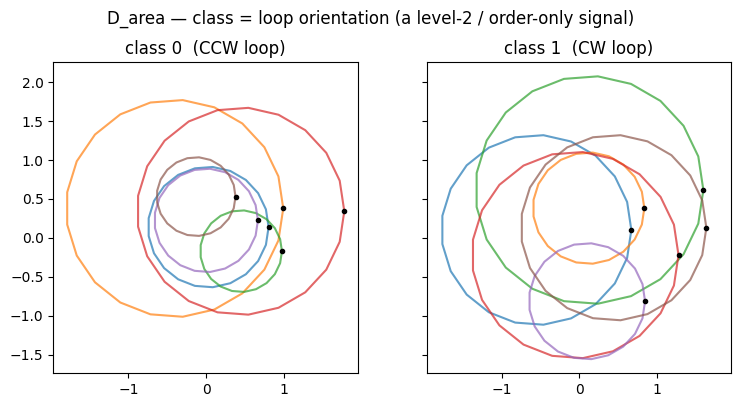

In [3]:
Xtr, ytr, _, _ = g.split(g.make_area, seed=list(g.DATASETS).index("D_area"))
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
for cls, a in zip((0, 1), ax):
    for i in np.where(ytr == cls)[0][:6]:
        a.plot(Xtr[i, :, 0], Xtr[i, :, 1], alpha=0.7)
        a.plot(*Xtr[i, 0], "ko", ms=3)
    a.set_title(f"class {cls}  ({'CCW' if cls == 0 else 'CW'} loop)"); a.set_aspect("equal")
fig.suptitle("D_area — class = loop orientation (a level-2 / order-only signal)")
plt.tight_layout(); plt.show()

## The confusion matrix — who reads what

For each DGP we fit the two learnable kernels on the **train** split, then score
**every** kernel out-of-sample by CKA on the **test** split (centered alignment
of the Gram with $yy^\top$ — the same objective `fit_phi` maximizes). The
per-row winner is boxed.

**Reference (CPU, `GeneralSignatureKernel`, 2026-06-11) — the predicted diagonal:**

```text
dataset      sig-L1  sig-TRUNC  sig-PDE  sig-Wphi  sig-PDEphi  sig-EXACT  pooled  kme
D_disp       +0.224  +0.240     +0.241   +0.248    +0.249      +0.229     +0.295  +0.278
D_area       +0.004  +0.875     +0.836   +0.915    +0.823      -0.008     +0.010  +0.009
D_peak       +0.015  +0.088     +0.085   +0.182    +0.047      +0.134     +0.008  +0.013
D_scale      +0.031  +0.255     +0.198   +0.800    +0.082      +0.079     +0.011  +0.125
D_lowsig     -0.005  +0.202     +0.379   +0.219    +0.433      -0.012     +0.013  +0.019
D_perlevel   +0.015  +0.052     +0.043   +0.098    +0.044      +0.171     +0.013  +0.009
```

The next cell recomputes this live (~30 s on CPU). Values move by a few points
with the backend RNG, but the **winner of each row is stable**.

[D_disp] sig-L1=+0.224  sig-TRUNC=+0.240  sig-PDE=+0.241  sig-Wphi=+0.248  sig-PDEphi=+0.249  sig-EXACT=+0.229  pooled-RBF=+0.295  kme-RBF=+0.278


[D_area] sig-L1=+0.004  sig-TRUNC=+0.875  sig-PDE=+0.836  sig-Wphi=+0.915  sig-PDEphi=+0.823  sig-EXACT=-0.008  pooled-RBF=+0.010  kme-RBF=+0.009


[D_peak] sig-L1=+0.015  sig-TRUNC=+0.088  sig-PDE=+0.085  sig-Wphi=+0.182  sig-PDEphi=+0.047  sig-EXACT=+0.134  pooled-RBF=+0.008  kme-RBF=+0.013


[D_scale] sig-L1=+0.031  sig-TRUNC=+0.255  sig-PDE=+0.198  sig-Wphi=+0.800  sig-PDEphi=+0.082  sig-EXACT=+0.079  pooled-RBF=+0.011  kme-RBF=+0.125


[D_lowsig] sig-L1=-0.005  sig-TRUNC=+0.202  sig-PDE=+0.379  sig-Wphi=+0.219  sig-PDEphi=+0.433  sig-EXACT=-0.012  pooled-RBF=+0.013  kme-RBF=+0.019


[D_perlevel] sig-L1=+0.015  sig-TRUNC=+0.052  sig-PDE=+0.043  sig-Wphi=+0.098  sig-PDEphi=+0.044  sig-EXACT=+0.171  pooled-RBF=+0.013  kme-RBF=+0.009


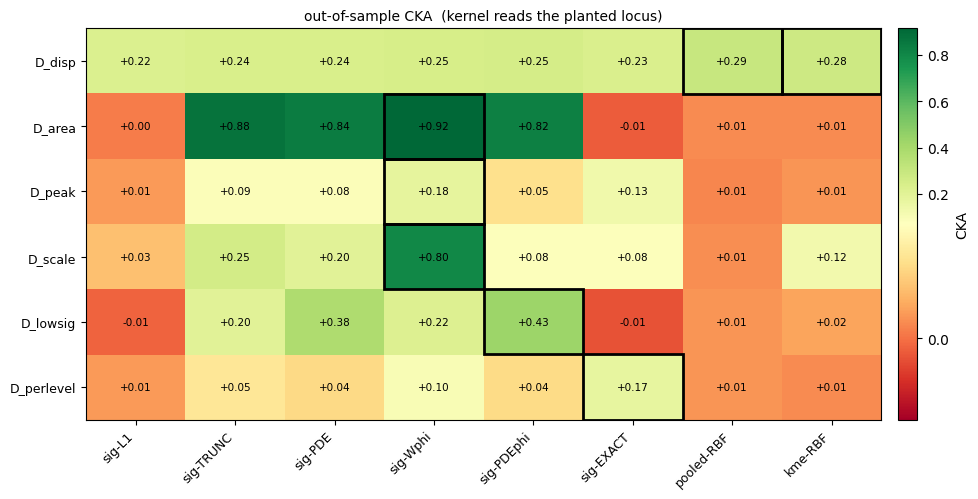

In [4]:
M = g.confusion_matrix()                 # {DGP: {kernel: out-of-sample CKA}}, ~30 s
g.plot_cka_heatmap(M); plt.show()

## Reading the matrix

* **`D_disp` (level 1).** Everything ties, and the order-blind `pooled-RBF` is
  *best* — a straight displacement needs no order, and the signature family
  manufactures no spurious order gain.
* **`D_area` (order).** The order-aware kernels jump to $0.82$–$0.92$ while every
  order-**blind** representation (`sig-L1`, `pooled-RBF`, `kme-RBF`) sits at
  chance. This is the signature kernel's reason to exist.
* **`D_peak`.** Signal at level 2 with noise at levels 1 **and** 3: the optimal
  $\varphi$ is a **non-monotone peak**. Only `sig-Wphi`'s free weights can
  represent it — the dilation cone and the uniform/per-level kernels cannot.
* **`D_scale` (tail).** The class lives in the level-$\ge$3 tail; free weights
  reach it, uniform `sig-PDE` partly, and the $\lambda_{\max}=0.5$ dilation cone
  (`sig-PDEphi`, forced *decaying*) cannot — the clamp chain `Wphi > PDE > PDEphi`.
* **`D_lowsig`.** Signal at level 2, noise in the tail: `sig-PDEphi`'s soft-decay
  $\varphi$ down-weights the tail and **beats uniform `sig-PDE`**.
* **`D_perlevel`.** A class-independent level-1 drift dominates the global norm;
  only `sig-EXACT`'s per-path, **per-level** whitening recovers the level-2 sign.

Two of these winners — `sig-Wphi` on `D_peak`/`D_scale` and `sig-PDEphi` on
`D_lowsig` — are kernels that **learned** their $\varphi$ from the data. That is
the subject of **`X_learned_kernel.ipynb`**: can the kernel *recover the order* a
process plants?